The dataset used was the Used Car Dataset with Price and Mileage from kaggle. https://www.kaggle.com/datasets/amisha1571/car-cleaned-dataset?resource=download

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/CarDetails.csv")

df.head()


#drop the unnamed column
df = df.drop(columns=["Unnamed: 0"])

df.head()

print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
display(df[["Year", "Price", "Kms_driven"]].describe())

Dataset shape: (815, 6)

Column types:
Name            str
Company         str
Year          int64
Price         int64
Kms_driven    int64
Fuel            str
dtype: object

Missing values:
Name          0
Company       0
Year          0
Price         0
Kms_driven    0
Fuel          0
dtype: int64

Summary statistics:


,Year,Price,Kms_driven
count,815.000000,8.150000e+02,815.000000
mean,2012.442945,4.017933e+05,46277.096933
std,4.005079,3.815888e+05,34318.459638
min,1995.000000,3.000000e+04,0.000000
25%,2010.000000,1.750000e+05,27000.000000
50%,2013.000000,2.999990e+05,41000.000000
75%,2015.000000,4.900000e+05,56879.000000
max,2019.000000,3.100000e+06,400000.000000


In [ ]:
#check correlation between Year, Kms_driven and Price
df[["Year", "Kms_driven", "Price"]].corr()


,Year,Kms_driven,Price
Year,1.000000,-0.233699,0.347764
Kms_driven,-0.233699,1.000000,-0.149621
Price,0.347764,-0.149621,1.000000


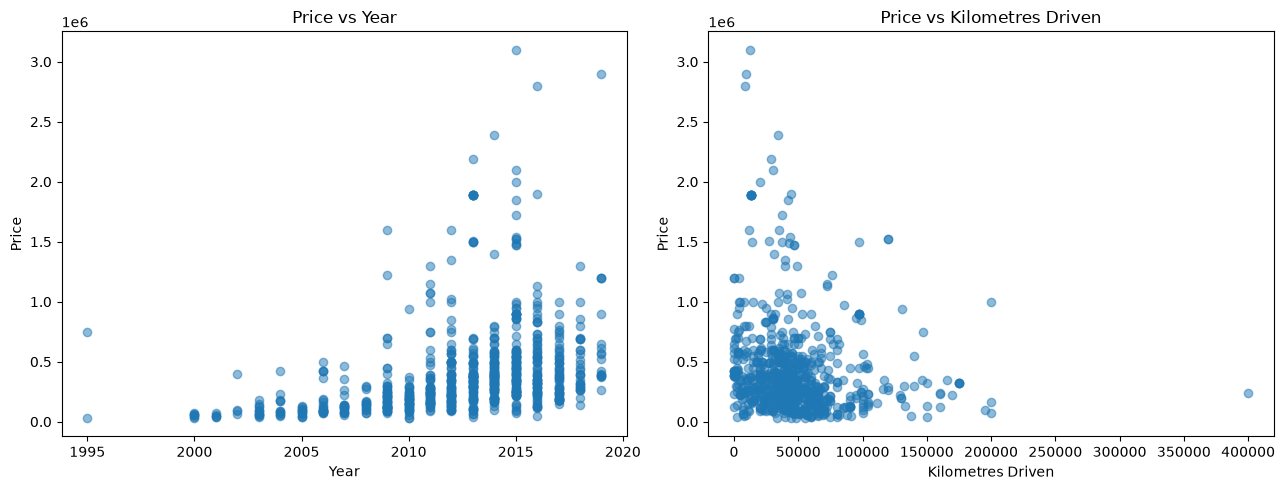

   Year  Kms_driven
0  2007       45000
1  2006          40
2  2014       28000
3  2014       36000
4  2012       41000
0     80000
1    425000
2    325000
3    575000
4    175000
Name: Price, dtype: int64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df["Year"], df["Price"], alpha=0.5)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price")
axes[0].set_title("Price vs Year")

axes[1].scatter(df["Kms_driven"], df["Price"], alpha=0.5)
axes[1].set_xlabel("Kilometres Driven")
axes[1].set_ylabel("Price")
axes[1].set_title("Price vs Kilometres Driven")

plt.tight_layout()
plt.show()

X = df[["Year", "Kms_driven"]]
y = df["Price"]

print(X.head())
print(y.head())

In [ ]:
#spliting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = mean_squared_error(y_test, linear_predictions) ** 0.5
linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression")
print(f"MAE:  {linear_mae:,.2f}") #the average size of the model's mistakes.
print(f"RMSE: {linear_rmse:,.2f}") #measures how wrong your predictions are
print(f"R²:   {linear_r2:.3f}")#measures how well your model explains the variation in car prices.

#the results show that linear regression is not a good model for this dataset.

Training rows: 652
Testing rows: 163
Linear Regression
MAE:  237,753.84
RMSE: 423,558.73
R²:   0.119


In [6]:
coefficients = pd.Series(
    linear_model.coef_,
    index=X.columns
)

print(coefficients)
print("Intercept:", linear_model.intercept_)

Year          29819.897479
Kms_driven       -0.514251
dtype: float64
Intercept: -59592474.817974575


In [8]:
#Rndom forest model
forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)
forest_mae = mean_absolute_error(y_test, forest_predictions)
forest_rmse = mean_squared_error(y_test, forest_predictions) ** 0.5
forest_r2 = r2_score(y_test, forest_predictions)

print("Random Forest")
print(f"MAE:  {forest_mae:,.2f}")
print(f"RMSE: {forest_rmse:,.2f}")
print(f"R²:   {forest_r2:.3f}")


Random Forest
MAE:  230,282.23
RMSE: 418,939.93
R²:   0.138


In [ ]:
#comparison table between the two models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, forest_mae],
    "RMSE": [linear_rmse, forest_rmse],
    "R²": [linear_r2, forest_r2]
})

results

#random forest model is better than linear regression model for this dataset. The random forest model has a lower MAE and RMSE, and a higher R² score, indicating that it is more accurate and explains more of the variation in car prices.

,Model,MAE,RMSE,R²
0,Linear Regression,237753.844789,423558.728398,0.119028
1,Random Forest,230282.232008,418939.930660,0.138137


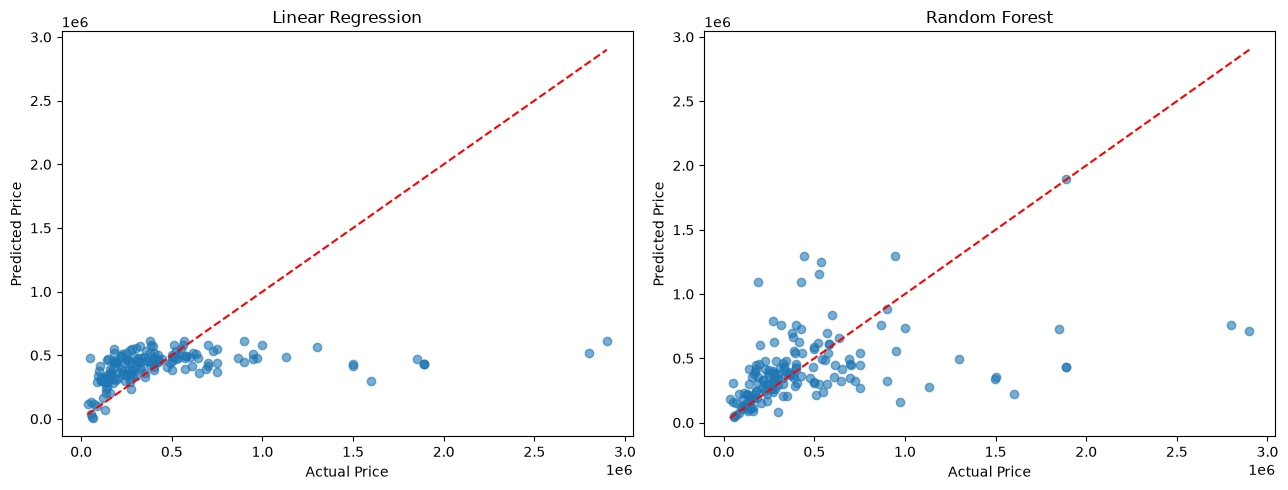

In [10]:
#actual verses predicted prices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, linear_predictions, alpha=0.6)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Linear Regression")

axes[1].scatter(y_test, forest_predictions, alpha=0.6)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()